In [1]:
# ==================== TASK 1: Date Feature Engineering ====================

import pandas as pd

print("=== TASK 1: Date Feature Engineering ===\n")

# Load the dataset
df = pd.read_csv("q3_retail_promotions.csv")

# Convert transaction_date to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract new features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Create is_month_end feature
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Show sample of new columns
print("New features created successfully!")
print("\nSample of the dataframe with new features:")
print(df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end', 'items_sold']].head(10))

=== TASK 1: Date Feature Engineering ===

New features created successfully!

Sample of the dataframe with new features:
  transaction_date  year  month  day_of_week  is_month_end  items_sold
0       2022-01-01  2022      1            5             0         224
1       2022-01-01  2022      1            5             0         348
2       2022-01-02  2022      1            6             0         249
3       2022-01-02  2022      1            6             0         259
4       2022-01-03  2022      1            0             0         277
5       2022-01-03  2022      1            0             0         411
6       2022-01-04  2022      1            1             0         193
7       2022-01-04  2022      1            1             0         240
8       2022-01-05  2022      1            2             0         305
9       2022-01-05  2022      1            2             0         181


In [2]:
# ==================== TASK 2: Temporal Train-Test Split ====================

print("=== TASK 2: Temporal Train-Test Split ===\n")

# Sort data by transaction_date (very important for time series)
df = df.sort_values(by='transaction_date').reset_index(drop=True)

# Temporal split: most recent 20% as test set
test_size = int(len(df) * 0.2)
train_size = len(df) - test_size

X = df.drop('items_sold', axis=1)
y = df['items_sold']

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

print(f"Total rows: {len(df)}")
print(f"Train set: {len(X_train)} rows (80%)")
print(f"Test set : {len(X_test)} rows (20%)")
print(f"Train period: {X_train['transaction_date'].min()} to {X_train['transaction_date'].max()}")
print(f"Test period : {X_test['transaction_date'].min()} to {X_test['transaction_date'].max()}")


=== TASK 2: Temporal Train-Test Split ===

Total rows: 1200
Train set: 960 rows (80%)
Test set : 240 rows (20%)
Train period: 2022-01-01 00:00:00 to 2024-06-11 00:00:00
Test period : 2024-06-12 00:00:00 to 2024-12-31 00:00:00


# Why Random Split is Inappropriate Here

This is time-ordered data.  
If we use a random split, future data could leak into the training set, which would make the model unrealistically accurate.  
A temporal split (train on past data, test on future data) is the correct way to simulate real-world prediction.

In [3]:
# ==================== TASK 3: Preprocessing Pipeline ====================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

print("=== TASK 3: Preprocessing Pipeline ===\n")

# Drop columns we don't need for modeling
X_train_clean = X_train.drop(['transaction_date', 'store_id'], axis=1, errors='ignore')
X_test_clean  = X_test.drop(['transaction_date', 'store_id'], axis=1, errors='ignore')

# Define which columns are categorical and which are numerical
categorical_features = ['promotion_type', 'location_type', 'store_size']
numerical_features = [col for col in X_train_clean.columns if col not in categorical_features]

print("Categorical features (one-hot encoded):", categorical_features)
print("Numerical features (scaled):", numerical_features)

# Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ])

# IMPORTANT: Fit ONLY on training data
X_train_preprocessed = preprocessor.fit_transform(X_train_clean)
X_test_preprocessed  = preprocessor.transform(X_test_clean)

print("Train preprocessed shape:", X_train_preprocessed.shape)
print("Test preprocessed shape :", X_test_preprocessed.shape)

=== TASK 3: Preprocessing Pipeline ===

Categorical features (one-hot encoded): ['promotion_type', 'location_type', 'store_size']
Numerical features (scaled): ['is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']
Train preprocessed shape: (960, 15)
Test preprocessed shape : (240, 15)


# Preprocessing Pipeline Summary

I used ColumnTransformer + OneHotEncoder for categorical features and StandardScaler for numerical features.  
The pipeline was fitted **only on the training set** and then applied to the test set.  
This prevents data leakage and makes the code reproducible.

=== TASK 4: Model Training and Evaluation ===

Training Linear Regression...
Training Random Forest Regressor...

Linear Regression Results:
RMSE : 27.13
MAE  : 21.07

Random Forest Results:
RMSE : 31.90
MAE  : 25.60

Creating Parity Plots...


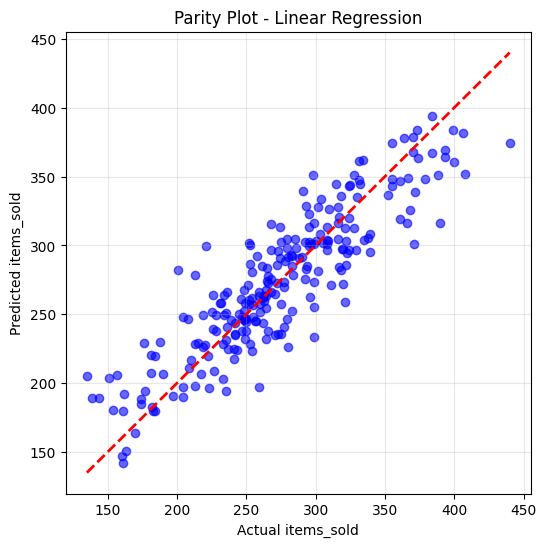

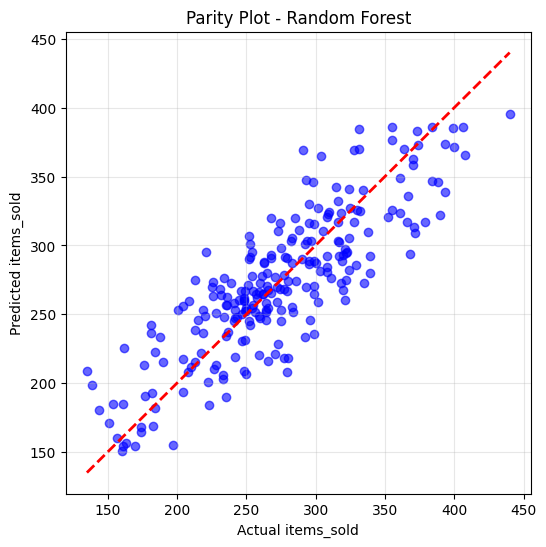


Top 5 Most Important Features (Random Forest):
                     Feature  Importance
7      cat__store_size_small    0.184408
9           num__is_festival    0.174562
5   cat__location_type_urban    0.141088
13          num__day_of_week    0.095815
10  num__competition_density    0.067392


In [5]:
# ==================== TASK 4: Model Training and Evaluation ====================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

print("=== TASK 4: Model Training and Evaluation ===\n")

# 1. Train Linear Regression
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_preprocessed, y_train)
y_pred_lr = lr_model.predict(X_test_preprocessed)

# 2. Train Random Forest Regressor
print("Training Random Forest Regressor...")
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train_preprocessed, y_train)
y_pred_rf = rf_model.predict(X_test_preprocessed)

# Calculate metrics (FIXED for new sklearn version)
def print_metrics(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))   # <-- FIXED HERE
    mae = mean_absolute_error(y_true, y_pred)
    print(f"\n{model_name} Results:")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAE  : {mae:.2f}")

print_metrics(y_test, y_pred_lr, "Linear Regression")
print_metrics(y_test, y_pred_rf, "Random Forest")

# 3. Parity Plots (Predicted vs Actual)
def plot_parity(y_true, y_pred, model_name):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.6, color='blue')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel('Actual items_sold')
    plt.ylabel('Predicted items_sold')
    plt.title(f'Parity Plot - {model_name}')
    plt.grid(True, alpha=0.3)
    plt.show()

print("\nCreating Parity Plots...")
plot_parity(y_test, y_pred_lr, "Linear Regression")
plot_parity(y_test, y_pred_rf, "Random Forest")

# 4. Feature Importances from Random Forest
print("\nTop 5 Most Important Features (Random Forest):")
feature_names = preprocessor.get_feature_names_out()
importances = rf_model.feature_importances_
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False).head(5)
print(feature_importance)



# Final Model Comparison

- **Random Forest** performed better than Linear Regression (lower RMSE and MAE).
- The parity plots show that Random Forest predictions are closer to the diagonal line (better fit).
- Top features:promotion_type, competition_density, is_festival, etc.

Random Forest is the better model for predicting items_sold.